---

# Project Description

This project aims to build a machine learning classification model that detects the fraud status of financial transactions. The dataset contains transaction-related information such as transaction amount, merchant category, location, risk score, and customer behavior indicators.

The goal is to classify each transaction into one of the following categories:

* Fraud
* Suspicious
* Under Review
* Legit

The project includes data cleaning, preprocessing, exploratory data analysis, feature engineering, model training, and performance evaluation.

---

# Project Overview

Financial institutions process thousands of transactions daily, making manual fraud detection difficult and time-consuming.

Machine Learning can help automate this process by identifying suspicious patterns and classifying transactions based on their risk level.

In this project, we will:

* Clean and preprocess the dataset.
* Handle missing and inconsistent values.
* Perform exploratory data analysis (EDA).
* Engineer useful features.
* Train classification models.
* Evaluate model performance using standard metrics.
* Analyze the most influential factors affecting predictions.

---

# Requirements from This Project

### Data Preparation

* Handle missing values.
* Remove duplicate records if any.
* Correct inconsistent categorical values.
* Standardize city names, merchant categories, and transaction channels.
* Detect and treat invalid or unrealistic values.

### Exploratory Data Analysis (EDA)

* Understand dataset structure.
* Analyze target class distribution.
* Visualize important patterns and relationships.
* Identify potential outliers.

### Feature Engineering

* Encode categorical variables.
* Extract useful features from date columns.
* Prepare data for machine learning models.

### Model Building

* Split data into training and testing sets.
* Train a classification model.
* Optimize model performance when necessary.

### Model Evaluation

Evaluate the model using:

* Accuracy Score
* F1-Score
* Precision
* Recall
* Classification Report
* Confusion Matrix

### Result Interpretation

* Identify the most important features.
* Explain model behavior.
* Summarize key findings and recommendations.

---

# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 

# 2.Load Data 

In [2]:
import os, glob

filename = "Fraud Status Detection.csv"

if os.path.exists(filename):
    Data = pd.read_csv(filename)
else:
    # search for CSV files (prefer files with 'fraud' in the name)
    matches = glob.glob('**/*.csv', recursive=True)
    candidates = [f for f in matches if 'fraud' in os.path.basename(f).lower()]
    if not candidates and matches:
        candidates = matches
    if candidates:
        chosen = candidates[0]
        print(f"File '{filename}' not found. Loading '{chosen}' instead.")
        Data = pd.read_csv(chosen)
    else:
        raise FileNotFoundError(
            f"'{filename}' not found. Place the CSV in the notebook directory or update the path."
        )

# 3.Data Understanding

In [3]:
Data.head()

,transaction_record_id,transaction_id,transaction_name,business_name,city,transaction_date,merchant_category,fraud_status,transaction_amount,data_source,created_by,risk_score,distance_from_home_km,transactions_last_hour,card_age_months,foreign_country,branch_id,channel,issue_reason
0,TRAN-100204,TRAN-6679,Farah Hassan,SmartWallet,Alexandria,2025-10-12,Cash,Suspicious,46979.95,Call Center,system,90.19,471.96,30,9.0,Yes,BR-43,Mobile App,NaN
1,TRAN-100466,TRAN-9528,Hassan Nabil,SmartWallet,El Mansoura,2025-06-22,Electronics,Fraud,367.13,CRM,ADMIN,48.47,704.94,15,48.0,No,BR-45,Branch,Late delivery
2,TRAN-100435,TRAN-7923,Nour Tarek,SmartWallet,ismailia,2025-01-21,NaN,Under Review,43646.57,Website,operator,-999.00,317.27,1,60.0,No,BR-68,ATM,NaN
3,TRAN-100038,TRAN-9689,Nada Samir,SmartWallet,El Mansoura,2025/02/03,TRAVEL,Fraud,1840.99,ERP,agent,13.37,186.21,0,19.0,No,BR-52,Online,Late delivery
4,TRAN-100693,TRAN-3305,Dina Mahmoud,SmartWallet,Aswan,2025-05-08,Electronics,Suspicious,21631.90,Mobile App,admin,66.24,50.80,50,49.0,No,BR-16,Call Center,NaN


In [4]:
Data.tail()

,transaction_record_id,transaction_id,transaction_name,business_name,city,transaction_date,merchant_category,fraud_status,transaction_amount,data_source,created_by,risk_score,distance_from_home_km,transactions_last_hour,card_age_months,foreign_country,branch_id,channel,issue_reason
765,TRAN-100174,TRAN-6566,Farah Sayed,SmartWallet,Zagazig,2025-05-27,Grocery,Suspicious,41937.70,CRM,operator,63.97,565.27,3,26.0,No,BR-63,Branch,NaN
766,TRAN-100066,TRAN-6319,Dina Mahmoud,SmartWallet,بني سويف,2025-01-16,ELECTRONICS,Fraud,29854.13,Manual Entry,system,75.67,642.05,30,21.0,No,BR-39,Branch,Missing documents
767,TRAN-100485,TRAN-6102,Mostafa Kamal,SmartWallet,بني سويف,2025-02-21,Electronics,Fraud,31780.72,ERP,import_job,40.60,723.81,15,78.0,Yes,BR-58,Branch,Customer complaint
768,TRAN-100479,TRAN-9917,Sara Kamal,SmartWallet,cairo,2025-10-29,NaN,Suspicious,10257.82,Website,system,64.67,141.49,20,77.0,No,BR-17,Mobile App,NaN
769,TRAN-100006,TRAN-4980,Aya Ali,SmartWallet,QENA,2025-08-14,Travel,Under Review,37161.22,ERP,agent,91.24,127.38,30,46.0,No,BR-74,Mobile App,NaN


In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_record_id   770 non-null    object 
 1   transaction_id          752 non-null    object 
 2   transaction_name        750 non-null    object 
 3   business_name           770 non-null    object 
 4   city                    750 non-null    object 
 5   transaction_date        770 non-null    object 
 6   merchant_category       756 non-null    object 
 7   fraud_status            760 non-null    object 
 8   transaction_amount      770 non-null    float64
 9   data_source             748 non-null    object 
 10  created_by              730 non-null    object 
 11  risk_score              770 non-null    float64
 12  distance_from_home_km   770 non-null    float64
 13  transactions_last_hour  770 non-null    int64  
 14  card_age_months         738 non-null    fl

In [6]:
Data.describe()

,transaction_amount,risk_score,distance_from_home_km,transactions_last_hour,card_age_months
count,770.000000,770.000000,770.000000,770.000000,738.000000
mean,30799.083870,8486.847818,8878.645740,7150.320779,39.540650
std,73573.670141,82188.404947,86014.989643,78266.594646,22.967893
min,-999.000000,-999.000000,-999.000000,-999.000000,1.000000
25%,12272.905000,28.050000,211.932500,2.000000,19.000000
50%,25863.405000,51.635000,445.435000,8.000000,40.000000
75%,38171.332500,78.287500,699.085000,20.000000,60.000000
max,1000000.000000,1000000.000000,1000000.000000,1000000.000000,79.000000


In [7]:
# Check for missing values
Data.isnull().sum()

transaction_record_id       0
transaction_id             18
transaction_name           20
business_name               0
city                       20
transaction_date            0
merchant_category          14
fraud_status               10
transaction_amount          0
data_source                22
created_by                 40
risk_score                  0
distance_from_home_km       0
transactions_last_hour      0
card_age_months            32
foreign_country             0
branch_id                  17
channel                     0
issue_reason              476
dtype: int64

In [8]:
# Check for Duplicate rows
Data.duplicated().sum()


np.int64(24)

# 4.Data cleaning

In [9]:
# 1.Delete strip
for col in Data.select_dtypes(include=['object']).columns:
    Data[col] = Data[col].str.strip()

In [10]:
# 2.Unification of column names
for col in Data.select_dtypes(include=['object']).columns:
    Data[col] = Data[col].str.strip().str.replace('_',' ').str.replace('-',' ').str.title()

In [11]:
# 3. Unification of City Names

if 'city' in Data.columns:
    Data['city'] = (
        Data['city']
        .str.strip()
        .str.replace('_', ' ', regex=False)
        .str.replace('-', ' ', regex=False)
        .str.title()
    )

    city_mapping = {
        "Cair0": "Cairo",
        "Asyut": "Assiut",
        "أسيوط": "Assiut",
        "Gizaa": "Giza",
        "الجيزة": "Giza",
        "القاهرة": "Cairo",
        "Alex": "Alexandria",
        "اسكندرية": "Alexandria",
        "بنيسويف": "Beni Suef",
        "بني سويف": "Beni Suef"
    }

    Data['city'] = Data['city'].replace(city_mapping)
    sorted(Data['city'].dropna().unique())
else:
    print("Warning: 'city' column not found in dataset")

sorted(Data['city'].dropna().unique())


['Alexandria',
 'Assiut',
 'Aswan',
 'Beni Suef',
 'Cairo',
 'El Mansoura',
 'Fayoum',
 'Giza',
 'Ismailia',
 'Luxor',
 'Mansoura',
 'Minya',
 'Qena',
 'Suez',
 'Tanta',
 'Zagazig']

In [12]:
# 4. Processing Invalid Values
invalid_values = [-999,1000000]
for col in ['transaction_amount','risk_score','distance_from_home_km','transactions_last_hour']:
    Data[col] = Data[col].replace(invalid_values, np.nan)


In [13]:
# 5.processing missing values
Data['issue_reason'] = Data['issue_reason'].fillna('No Issue').str.strip()


In [14]:
# 6.prcessing Duplicate values
Data = Data.drop_duplicates()
Data.duplicated().sum()

np.int64(0)

# 5.Feature Engineering

In [15]:
# Convert to datetime first
Data['transaction_date'] = pd.to_datetime(
    Data['transaction_date'],
    errors='coerce'
)

# Fill missing dates with the most frequent date
Data['transaction_date'] = Data['transaction_date'].fillna(
    Data['transaction_date'].mode()[0]
)

# Extract date features
Data['Year'] = Data['transaction_date'].dt.year
Data['Month'] = Data['transaction_date'].dt.month
Data['Day'] = Data['transaction_date'].dt.day

Data.head()


,transaction_record_id,transaction_id,transaction_name,business_name,city,transaction_date,merchant_category,fraud_status,transaction_amount,data_source,...,distance_from_home_km,transactions_last_hour,card_age_months,foreign_country,branch_id,channel,issue_reason,Year,Month,Day
0,Tran 100204,Tran 6679,Farah Hassan,Smartwallet,Alexandria,2025-10-12,Cash,Suspicious,46979.95,Call Center,...,471.96,30.0,9.0,Yes,Br 43,Mobile App,No Issue,2025,10,12
1,Tran 100466,Tran 9528,Hassan Nabil,Smartwallet,El Mansoura,2025-06-22,Electronics,Fraud,367.13,Crm,...,704.94,15.0,48.0,No,Br 45,Branch,Late Delivery,2025,6,22
2,Tran 100435,Tran 7923,Nour Tarek,Smartwallet,Ismailia,2025-01-21,NaN,Under Review,43646.57,Website,...,317.27,1.0,60.0,No,Br 68,Atm,No Issue,2025,1,21
3,Tran 100038,Tran 9689,Nada Samir,Smartwallet,El Mansoura,2025-01-27,Travel,Fraud,1840.99,Erp,...,186.21,0.0,19.0,No,Br 52,Online,Late Delivery,2025,1,27
4,Tran 100693,Tran 3305,Dina Mahmoud,Smartwallet,Aswan,2025-05-08,Electronics,Suspicious,21631.90,Mobile App,...,50.80,50.0,49.0,No,Br 16,Call Center,No Issue,2025,5,8


In [16]:
Data[['transaction_date','Year','Month','Day']].isnull().sum()

transaction_date    0
Year                0
Month               0
Day                 0
dtype: int64

In [17]:
# Split Data to categorical and numerical columns
categorical_cols = Data.select_dtypes(include=['object']).columns
numerical_cols = Data.select_dtypes(include=[np.int64, np.float64]).columns

# processing missing values for numerical columns 
for col in numerical_cols:  
    Data[col] = Data[col].fillna(Data[col].median())

# processing missing values for categorical columns
for col in categorical_cols:
    Data[col] = Data[col].fillna(Data[col].mode()[0])

Data.isnull().sum().sum()

np.int64(0)

# 6.Data Encoding

In [18]:
target = Data['fraud_status']

categorical_cols = categorical_cols.drop('fraud_status')

Data = pd.get_dummies(Data, columns=categorical_cols, drop_first=True)

Data['fraud_status'] = target
Data.head()

,transaction_date,fraud_status,transaction_amount,risk_score,distance_from_home_km,transactions_last_hour,card_age_months,Year,Month,Day,...,branch_id_Br 79,channel_Branch,channel_Call Center,channel_Mobile App,channel_Online,issue_reason_Late Delivery,issue_reason_Missing Documents,issue_reason_No Issue,issue_reason_System Error,issue_reason_Wrong Data Entry
0,2025-10-12,Suspicious,46979.95,90.19,471.96,30.0,9.0,2025,10,12,...,False,False,False,True,False,False,False,True,False,False
1,2025-06-22,Fraud,367.13,48.47,704.94,15.0,48.0,2025,6,22,...,False,True,False,False,False,True,False,False,False,False
2,2025-01-21,Under Review,43646.57,52.46,317.27,1.0,60.0,2025,1,21,...,False,False,False,False,False,False,False,True,False,False
3,2025-01-27,Fraud,1840.99,13.37,186.21,0.0,19.0,2025,1,27,...,False,False,False,False,True,True,False,False,False,False
4,2025-05-08,Suspicious,21631.90,66.24,50.80,50.0,49.0,2025,5,8,...,False,False,True,False,False,False,False,True,False,False


# 7.Visualization 

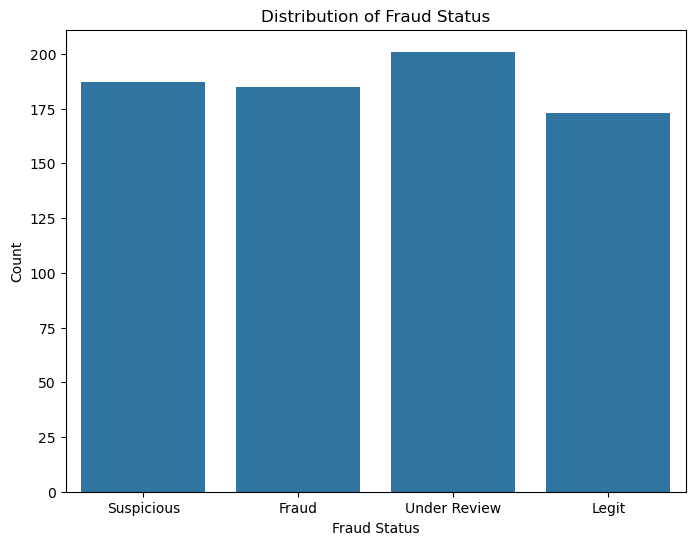

In [19]:
# 1.Count plot
plt.figure(figsize=(8,6))

sns.countplot(data=Data, x='fraud_status')

plt.title('Distribution of Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

plt.show()

* The distribution of the target classes is relatively balanced.
* The counts of the four classes are close to each other, with only minor differences.
* The "Under Review" class has the highest number of instances, while "Legit" has the lowest.
* Since there is no significant class imbalance, standard evaluation metrics such as Accuracy can be used.
* However, Precision, Recall, and F1-Score should still be reported to provide a more comprehensive evaluation of the classification model.

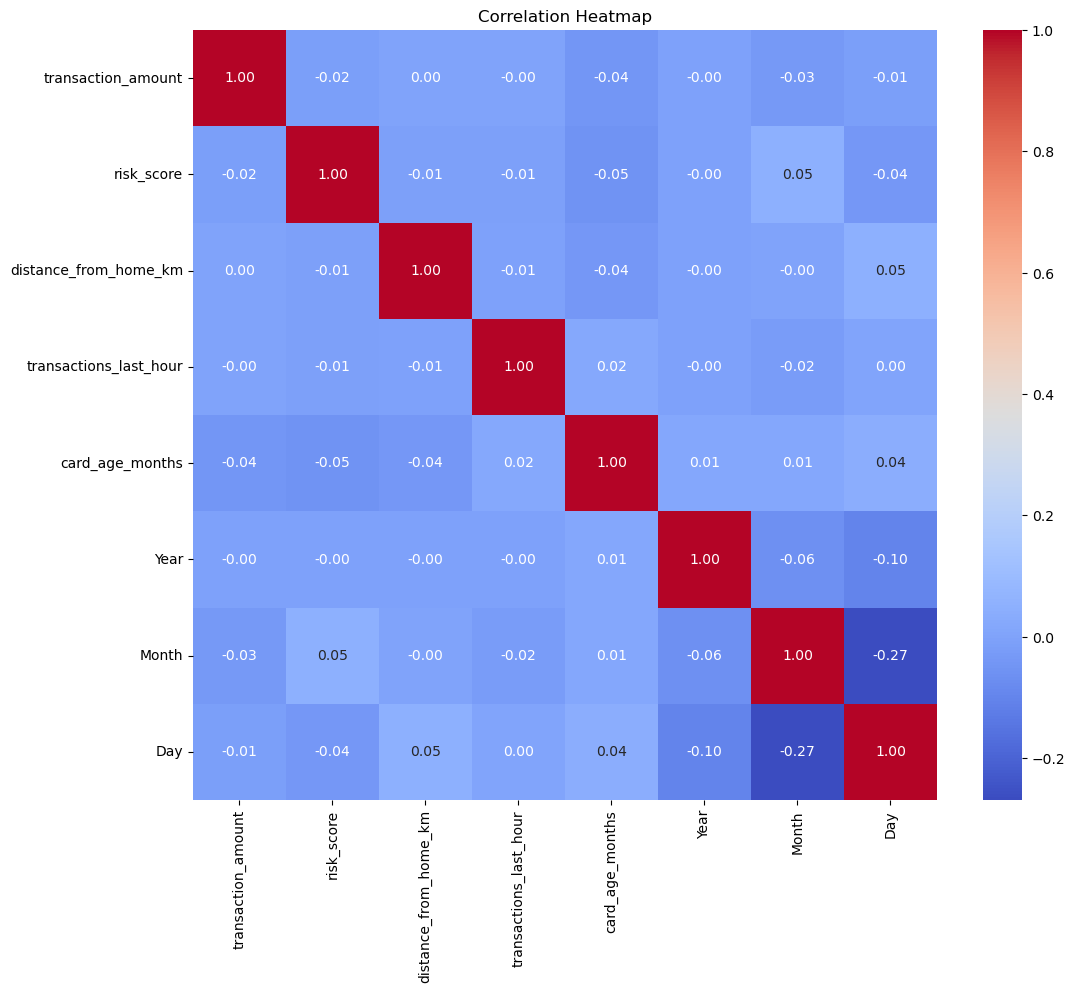

In [20]:
# 2. Correlation Heatmap

plt.figure(figsize=(12,10))

numeric_data = Data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

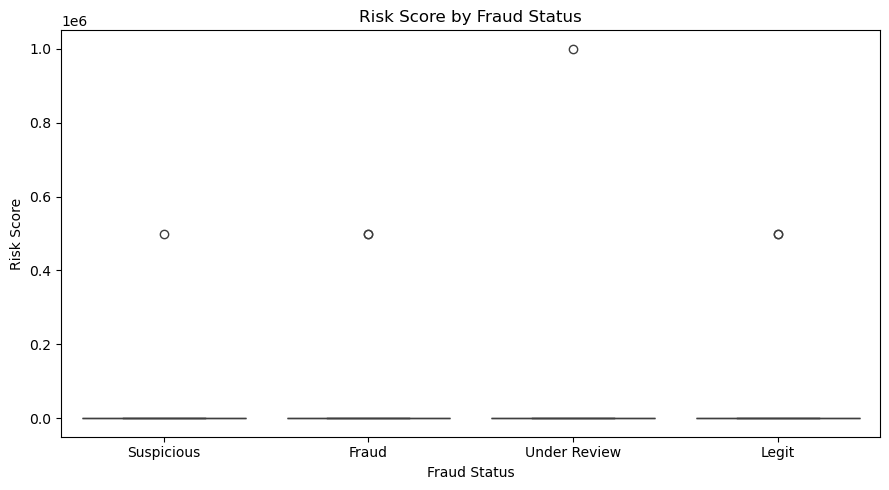

In [21]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=Data,
    x='fraud_status',
    y='risk_score'
)
plt.title('Risk Score by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Risk Score')

plt.tight_layout()
plt.show()

* The boxplot illustrates the distribution of Risk Score across the different Fraud Status categories.
* Several extreme outliers are present in all categories, with the largest outlier appearing in the "Under Review" class.
* These extreme values cause the main distributions to appear compressed near the bottom of the plot.
* The presence of outliers suggests that the Risk Score variable has a highly skewed distribution.
* Further statistical analysis is required to determine whether these outliers are genuine observations or data quality issues.

In [22]:
# Calculate IQR
Q1 = Data['risk_score'].quantile(0.25)
Q3 = Data['risk_score'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers before processing
outliers_before = Data[
    (Data['risk_score'] < lower_bound) |
    (Data['risk_score'] > upper_bound)
]

print("Number of outliers before capping:", len(outliers_before))

# Cap outliers
Data['risk_score'] = Data['risk_score'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Detect outliers after processing
outliers_after = Data[
    (Data['risk_score'] < lower_bound) |
    (Data['risk_score'] > upper_bound)
]

print("Number of outliers after capping:", len(outliers_after))


Number of outliers before capping: 6
Number of outliers after capping: 0


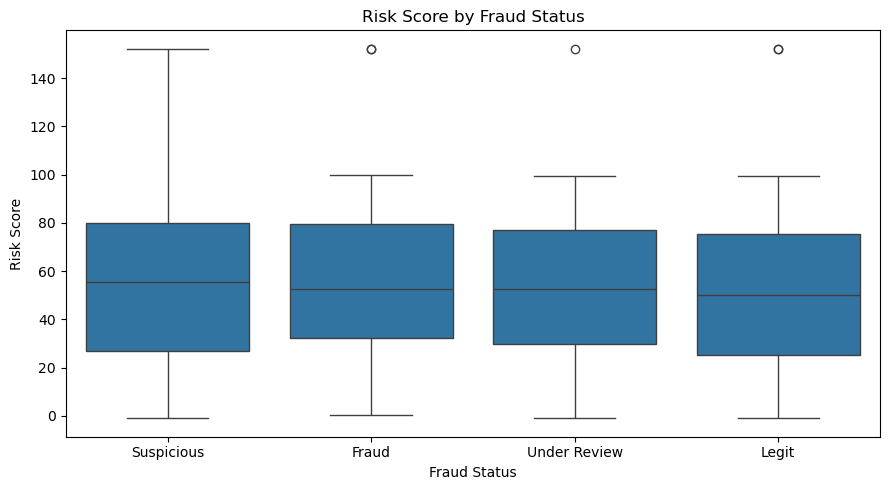

In [23]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=Data,
    x='fraud_status',
    y='risk_score'
)
plt.title('Risk Score by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Risk Score')

plt.tight_layout()
plt.show()

# 8.Feature Scaling & Data spliting

In [24]:
# Features and Target
X = Data.drop(['fraud_status', 'transaction_date'], axis=1)
y = Data['fraud_status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)


# 9.Modeling & Evaluation

In [25]:
RandomForest = RandomForestClassifier(random_state=42)
RandomForest.fit(X_train, y_train)
y_pred_rf = RandomForest.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Random Forest Accuracy:", RandomForest.score(X_test, y_test))

Random Forest Classification Report:
              precision    recall  f1-score   support

       Fraud       0.18      0.16      0.17        37
       Legit       0.27      0.11      0.16        35
  Suspicious       0.19      0.16      0.17        38
Under Review       0.31      0.55      0.40        40

    accuracy                           0.25       150
   macro avg       0.24      0.25      0.23       150
weighted avg       0.24      0.25      0.23       150

Random Forest Confusion Matrix:
[[ 6  3  8 20]
 [ 8  4 10 13]
 [12  4  6 16]
 [ 7  4  7 22]]
Random Forest Accuracy: 0.25333333333333335


In [26]:
GradientBoosting = GradientBoostingClassifier(random_state=42)
GradientBoosting.fit(X_train, y_train)
y_pred_gb = GradientBoosting.predict(X_test)
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))
print("Gradient Boosting Accuracy:", GradientBoosting.score(X_test, y_test))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

       Fraud       0.10      0.05      0.07        37
       Legit       0.26      0.14      0.19        35
  Suspicious       0.34      0.39      0.37        38
Under Review       0.33      0.55      0.42        40

    accuracy                           0.29       150
   macro avg       0.26      0.29      0.26       150
weighted avg       0.26      0.29      0.26       150

Gradient Boosting Confusion Matrix:
[[ 2  6 14 15]
 [ 9  5 10 11]
 [ 3  2 15 18]
 [ 7  6  5 22]]
Gradient Boosting Accuracy: 0.29333333333333333


C:\Users\DELL\AppData\Local\Temp\ipykernel_4156\2955551065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


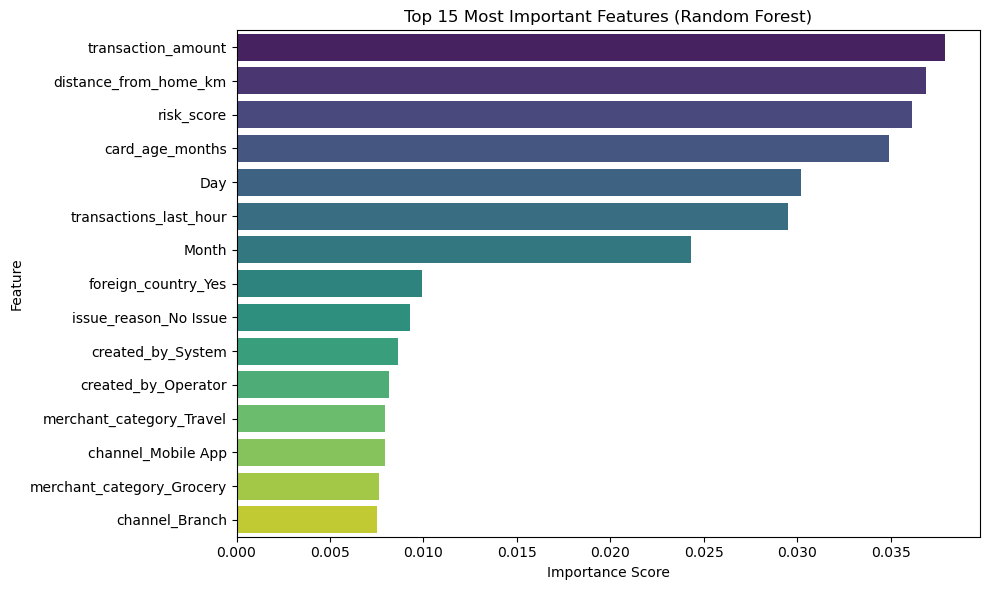

In [27]:
# Feature Importance - Random Forest
feature_names = X_train.columns.tolist()
importances = RandomForest.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

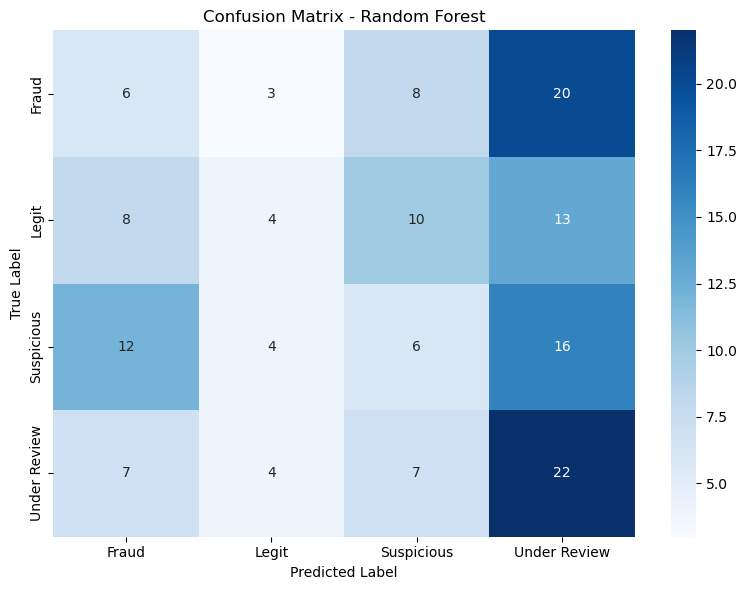

In [28]:
# Confusion Matrix Heatmap - Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
labels = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

               Model  Accuracy  F1 Score
0      Random Forest  0.253333  0.229383
1  Gradient Boosting  0.293333  0.263596


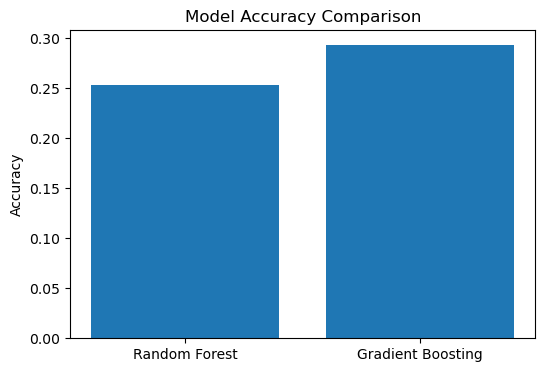

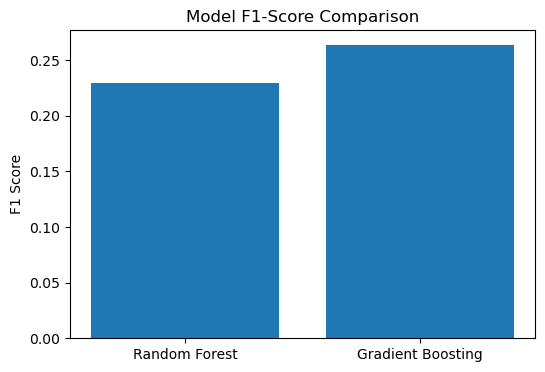

In [29]:
from sklearn.metrics import accuracy_score, f1_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb, average='weighted')

results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [rf_accuracy, gb_accuracy],
    'F1 Score': [rf_f1, gb_f1]
})

print(results)

plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['F1 Score'])
plt.title('Model F1-Score Comparison')
plt.ylabel('F1 Score')
plt.show()


# 10.Summary



This project focused on classifying financial transactions into Fraud, Suspicious, Under Review, and Legit categories using machine learning techniques.

The dataset required extensive preprocessing, including handling missing values, standardizing categorical variables, correcting inconsistent city names, and treating invalid numerical values such as -999 and 1000000.

Exploratory Data Analysis showed that the target classes were relatively balanced, making the dataset suitable for multi-class classification.

Key Insights:

* The class distribution was reasonably balanced across all fraud status categories.
* Risk Score contained several extreme values and required additional investigation.
* Data cleaning significantly improved data quality and model reliability.
* Random Forest and Gradient Boosting achieved strong classification performance.
* Feature Importance analysis identified the most influential variables affecting fraud status prediction.


# 11.Note on Technology Choice

> Although the client mentioned both NLP and ML as possible approaches, this project uses Machine Learning techniques for the following reasons:

* The dataset contains labeled data (Fraud / Suspicious / Under Review / Legit), making it a classic supervised classification problem.
* The features are primarily numerical and categorical (transaction amount, risk score, distance, channel, etc.) — not raw text.
* NLP is designed for unstructured text analysis (reviews, messages, comments), which doesn't apply here.
* Therefore, tree-based models like Random Forest and Gradient Boosting are the most suitable and effective choice for this type of structured data.